<a href="https://colab.research.google.com/github/praveenbunker/data-science-project/blob/main/Retail_Customer_Purchase_Prediction/Retail_Customer_Purchase_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print(df.shape)
df.head()

Saving online_shoppers_purchasing_intention.csv to online_shoppers_purchasing_intention.csv
(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
print(df["Revenue"].value_counts())

Revenue
False    10422
True      1908
Name: count, dtype: int64


Categorical columns ko numbers mein convert karo

In [6]:
le = LabelEncoder()

df["Month"] = le.fit_transform(df["Month"])
df["VisitorType"] = le.fit_transform(df["VisitorType"])
df["Weekend"] = le.fit_transform(df["Weekend"])
df["Revenue"] = le.fit_transform(df["Revenue"])

In [7]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

## ***Train/Test Split***

### Maine dataset ko 80% training data aur 20% testing data mein baant diya

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9864, 17)
Testing data: (2466, 17)


## ***Logistic Regression***

In [14]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

# prediction

In [10]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 1 0]


# ***Accuracy***

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8706407137064072


## ***Confusion Matrix***

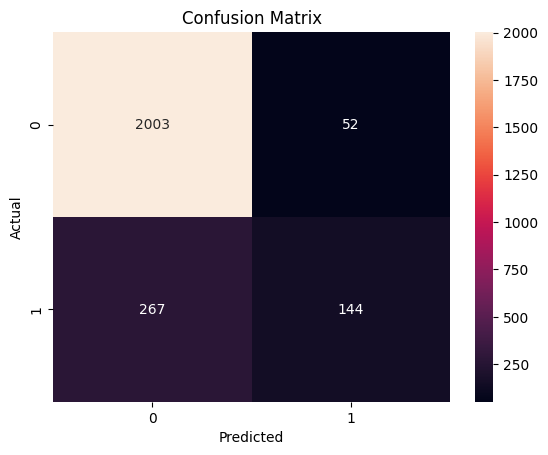

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ***Purchase Distribution***

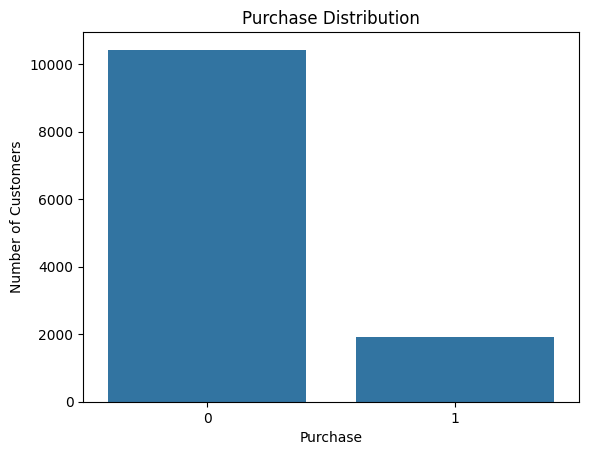

In [13]:
sns.countplot(x="Revenue", data=df)

plt.title("Purchase Distribution")
plt.xlabel("Purchase")
plt.ylabel("Number of Customers")

plt.show()

Humne do models try kiye — Logistic Regression aur Random Forest. Logistic Regression ki accuracy around 87% aur Random Forest ki accuracy around 89.66% aayi

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8965936739659367


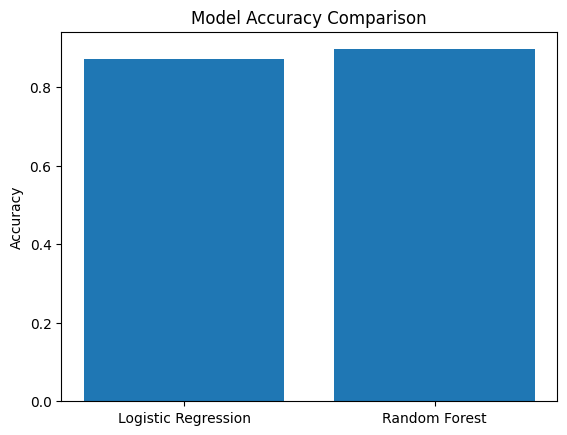

In [16]:
models = ["Logistic Regression", "Random Forest"]
accuracy = [0.8707, rf_accuracy]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

### Isse hume pata chalega ki Random Forest ne kitne customers ko correctly/incorrectly predict kiya

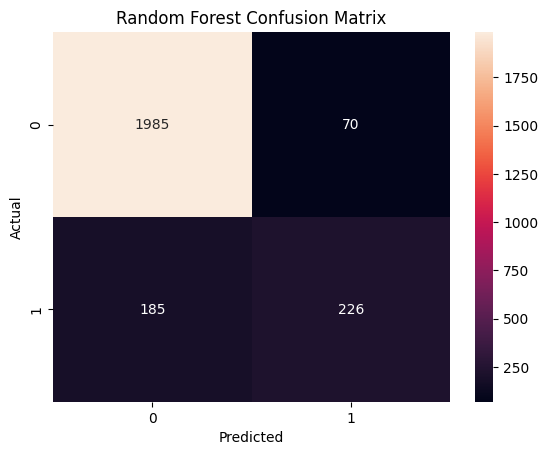

In [17]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### *Random Forest sirf purchase ya no-purchase predict nahi karta, hum predict_proba() se customer ke purchase karne ki probability bhi nikal sakte hain*

In [18]:
probability = rf_model.predict_proba(X_test)[:, 1]

print("First 10 Purchase Probabilities:")
print(probability[:10])

First 10 Purchase Probabilities:
[0.04 0.27 0.42 0.56 0.46 0.   0.   0.   0.49 0.01]


### *probability ko Low / Medium / High Intent mein divide karenge*

In [19]:
def intent(prob):
    if prob < 0.30:
        return "Low"
    elif prob < 0.70:
        return "Medium"
    else:
        return "High"

intent_result = [intent(p) for p in probability]

print(intent_result[:10])

['Low', 'Low', 'Medium', 'Medium', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low']


In [22]:
print("FINAL PROJECT RESULTS")
print("---------------------")

print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

FINAL PROJECT RESULTS
---------------------
Logistic Regression Accuracy: [0.8707, 0.8965936739659367]
Random Forest Accuracy: 0.8965936739659367


In [23]:
print("FINAL PROJECT RESULTS")
print("---------------------")

print("Logistic Regression Accuracy:", accuracy * 100, "%")
print("Random Forest Accuracy:", rf_accuracy * 100, "%")

FINAL PROJECT RESULTS
---------------------
Logistic Regression Accuracy: [0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0.8707, 0.8965936739659367, 0

In [24]:
import joblib

joblib.dump(rf_model, "retail_purchase_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [25]:
from google.colab import files

files.download("retail_purchase_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>